# 13 - Node Embeddings and Link Prediction

In this notebook we want to see what a Node2Vec representation of the station graph is actually useful for. We learn a 64-dimensional vector for each station and use those vectors for four things: predicting missing edges, finding structurally similar stations, suggesting non-adjacent station pairs, and classifying structurally critical stations.

The main thing we need to get right is the order of the link-prediction experiment. We have to remove the test edges **before** learning the embeddings. If we learn on the complete graph, the random walks already cross the edges we later pretend are unknown, so the test becomes a memory check. We keep one deliberately leaked run only as a diagnostic, clearly separated from the valid results.

The questions we want to answer are:

1. How do Node2Vec features compare with simple neighborhood scores on genuinely unseen edges?
2. How much do the scores change when we replace easy random negatives with plausible two-hop non-edges?
3. Are high-cosine non-edges useful candidates for new links, and do 20 such links change robustness at all?
4. Do these embeddings contain enough information to recognize articulation points and high-betweenness stations?

We load the graph made in notebook 02 when it is available. The outputs go to `outputs/nb/13_embeddings_link_prediction/`: evaluation tables, both embedding matrices, suggested links, the resilience comparison, classifier results, station-neighbor checks, and the figures used to inspect the embedding space.

## Setting up the working environment

We start by finding the repository root, switching into it, and creating the common output directory. The helper also makes the notebook usable in Colab by cloning the repository only when it cannot find the GTFS folder locally. We can rerun this cell safely because it only installs missing packages or creates folders that do not exist.

In [22]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Python 3.14.5 -> /Users/seanfourman/Desktop/israel-transit-network-resilience/.venv/bin/python
Repo root: /Users/seanfourman/Desktop/israel-transit-network-resilience


## Libraries

We load the graph, data, plotting, and machine-learning libraries used below. Skip-gram Word2Vec would normally turn the random-walk sequences into station vectors, but `gensim` publishes no wheel for the Python version this project runs on and its source build fails. The `node2vec` package depends on `gensim`, so it is used only when it already happens to be installed. We therefore learn the vectors with SciPy and scikit-learn instead, from exactly the same walks.

With `p = q = 1`, there is no second-order Node2Vec bias, so the walk is just a first-order weighted random walk: neighboring stations are chosen in proportion to the segment's trip-frequency weight.

In [23]:
_ensure("numpy", "pandas", "networkx", "scikit-learn", "matplotlib", "seaborn")

# gensim - and node2vec, which depends on it - publish no wheel for this Python and
# fail to build from source, so neither is installed here. The walks are unchanged;
# only the step that turns them into vectors uses scikit-learn instead of Word2Vec.
import importlib.util
HAS_NODE2VEC = importlib.util.find_spec("node2vec") is not None

import csv, hashlib, json, math, pickle, random, time
from collections import defaultdict

import numpy as np
import pandas as pd
import networkx as nx
from scipy import sparse
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             classification_report, confusion_matrix)

print("networkx", nx.__version__)
print("node2vec package available:", HAS_NODE2VEC)

networkx 3.6.1
node2vec package available: False


## Handling Hebrew labels

Station names are stored in Hebrew, so we set a font that contains Hebrew glyphs before making any figures. In this Matplotlib build the raw logical-order Hebrew text is already handled correctly, so `fix_he` intentionally leaves strings unchanged. We do not pre-reorder the text with `python-bidi`, because that would reverse it a second time in this environment.

In [24]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# We do not pre-reorder it with python-bidi because that would reverse it a second time.
# fix_he is a no-op here, and we only select a Hebrew-capable font. (If Hebrew renders
# reversed on some other matplotlib build that has no native bidi, that build would need
# get_display; this one does not.)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # If an earlier run left a bidi patch on Text.set_text, remove it so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

import seaborn as sns
sns.set_theme(style="whitegrid", font_scale=1.0)
install_hebrew()  # seaborn resets rcParams, so re-apply the font settings

## Constants and runtime budget

We keep all sampling sizes, model settings, and seeds in one cell so we can see exactly what controls the experiment. The two embedding fits are the main cost: one on the training graph for valid link prediction and one on the complete largest component for descriptive work and the leakage diagnostic. CCPA requires shortest-path searches for sampled pairs, approximate betweenness supplies the criticality labels, nearest neighbors support the link suggestions, and t-SNE is limited to a subsample.

On this graph of roughly 30,000 stations and 52,000 edges, the full notebook can take around 15-35 minutes depending on the machine. `N2V_WORKERS = 1` and the fixed seeds favor reproducibility over speed. We can reduce the sample constants while testing the notebook, but the saved results should use the values defined here.

In [25]:
SEED = 42

# --- Random-walk embedding hyperparameters for this run --------------------
EMBEDDING_DIM = 64      # embedding dimensionality
WALK_LENGTH = 20        # nodes visited per random walk
NUM_WALKS = 5           # walks started from every node
WINDOW = 5              # skip-gram context window
EPOCHS = 3              # Word2Vec passes over the walk corpus (node2vec backend only)
SVD_NEG_SAMPLES = 5     # negative samples the PPMI shift emulates: PMI - log(k)
N2V_WORKERS = 1         # 1 keeps the run bit-for-bit reproducible; >1 is faster but not
EMBED_BACKEND = "auto"  # "auto" | "node2vec" | "inline"
REUSE_EMBEDDING_CACHE = True  # validated cache avoids retraining on every rerun

# --- Link-prediction protocol ---
TEST_FRAC = 0.10        # share of edges held out as positive test examples
NEG_RATIO = 1.0         # negatives per positive
MAX_TRAIN_PAIRS = 20000 # cap on pairs used to fit the link-prediction classifier
CCPA_ALPHA = 0.8        # alpha of the CCPA score (see the CCPA section)
CCPA_MAX_PAIRS = 2000   # CCPA needs a shortest path per pair, so it is subsampled
RUN_LEAKAGE_DIAGNOSTIC = True

# --- Suggested links / resilience ---
TOP_K_SUGGEST = 20
SIM_TOP_M = 25          # neighbours kept per node when searching for the global top-K
REMOVAL_K_GRID = [50, 200, 500, 1000, 2000]

# --- Criticality labels and visualisation ---
BETWEENNESS_SAMPLES = 300  # pivot nodes for approximate betweenness (exact is infeasible)
BETWEENNESS_QUANTILE = 0.90
TSNE_SAMPLE = 6000

STAGE = OUT / "13_embeddings_link_prediction"
TABLES = STAGE / "tables"
FIGURES = STAGE / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
print("Stage folder:", STAGE)

Stage folder: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/13_embeddings_link_prediction


## Loading the graph

We use the undirected trip-adjacency graph: each node is an active station, each edge joins stations that occur consecutively on at least one trip, and the edge weight is the number of trips using that segment. The loader first looks for the graph pickle from notebook 02 and then for its node and edge CSV files.

This cell only loads and validates an existing graph. If neither form is present, it leaves `G` empty so the next cell can build the same object directly from the feed.

In [26]:
PREV = OUT / "02_graph_construction"

def _to_float(x):
    """Best-effort float conversion; returns None for blanks and NaN."""
    try:
        v = float(x)
    except (TypeError, ValueError):
        return None
    return v if v == v else None

def _graph_from_csv(nodes_csv, edges_csv):
    """Rebuild the undirected weighted graph from stage-02 CSV exports."""
    edges = pd.read_csv(edges_csv, encoding="utf-8-sig")
    cols = list(edges.columns)
    src = "from_stop" if "from_stop" in cols else cols[0]
    dst = "to_stop" if "to_stop" in cols else cols[1]
    wcol = next((c for c in ("trip_frequency", "weight", "count") if c in cols), None)
    arr = edges[[src, dst]].astype(str).values
    wts = edges[wcol].astype(float).values if wcol else np.ones(len(edges))
    H = nx.Graph()
    for (u, v), w in zip(arr, wts):
        if u == v:
            continue
        if H.has_edge(u, v):
            H[u][v]["weight"] += float(w)
        else:
            H.add_edge(u, v, weight=float(w))
    if nodes_csv is not None and Path(nodes_csv).exists():
        nodes = pd.read_csv(nodes_csv, dtype=str, encoding="utf-8-sig", keep_default_na=False)
        for r in nodes.to_dict("records"):
            nid = str(r.get("stop_id", ""))
            if nid in H:
                H.nodes[nid].update({
                    "stop_name": r.get("stop_name", ""),
                    "lat": _to_float(r.get("lat", r.get("stop_lat"))),
                    "lon": _to_float(r.get("lon", r.get("stop_lon"))),
                    "region": r.get("region", ""),
                    "metro": r.get("metro", ""),
                })
    return H

def load_stage02_graph():
    """Return the undirected stage-02 graph, or None when the stage has not been run."""
    if not PREV.exists():
        return None
    for p in sorted(PREV.glob("**/*.pkl")):
        name = p.name.lower()
        if "directed" in name and "undirected" not in name:
            continue
        try:
            with open(p, "rb") as f:
                obj = pickle.load(f)
        except Exception as exc:
            print("Could not read", p, "-", exc)
            continue
        if isinstance(obj, nx.Graph) and not obj.is_directed():
            print("Loaded stage-02 graph from", p)
            return obj
    edges_csv = next(iter(sorted(PREV.glob("**/edges.csv"))), None)
    nodes_csv = next(iter(sorted(PREV.glob("**/nodes.csv"))), None)
    if edges_csv is not None:
        print("Rebuilding graph from stage-02 CSVs:", edges_csv)
        return _graph_from_csv(nodes_csv, edges_csv)
    return None

G = load_stage02_graph()
if G is None:
    print("No stage-02 artifacts under", PREV)
    print("Falling back to building the graph from the raw GTFS feed in the next cell.")
    print("Run notebook 02_graph_construction first to skip the 816 MB download.")
else:
    print(f"Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Loaded stage-02 graph from /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction/graph_undirected.pkl
Graph: 30,463 nodes, 51,772 edges


### Fallback: rebuilding the graph from the GTFS feed

We only enter this branch when notebook 02's graph is unavailable. The code downloads `stop_times.txt` if needed, streams it one row at a time, and treats consecutive rows from the same trip as directed station segments. Streaming matters because the file is about 816 MB and does not need to be held in memory.

We count repeated segments as trip-frequency weights, collapse both directions into one undirected edge, and attach names, coordinates, and area labels from `stops.txt`. The result has the same node and weight meaning as the graph loaded above, so the rest of the notebook does not care which path produced it.

In [27]:
if G is None:
    # stop_times.txt is 816MB and is not tracked in git - fetch it on demand.
    _ensure("gdown")
    import gdown
    STOP_TIMES = DATA / "stop_times.txt"
    if not STOP_TIMES.exists():
        gdown.download(id="1V_yPAWXV6mGTFGrfiosah5LngcLZnviW",
                       output=str(STOP_TIMES), quiet=False)
    print("stop_times.txt:", round(STOP_TIMES.stat().st_size / 1024**2, 1), "MB")

    csv.field_size_limit(10_000_000)

    def assign_region(lat, lon):
        """Coarse geographic region, same cut-offs as the data-preparation stage."""
        if 31.70 <= lat <= 31.90 and 34.95 <= lon <= 35.30:
            return "Jerusalem"
        if lat > 32.50:
            return "North"
        if lat >= 31.55:
            return "Center"
        return "South"

    stops = pd.read_csv(DATA / "stops.txt", dtype=str, keep_default_na=False,
                        encoding="utf-8-sig")
    stops["stop_lat"] = pd.to_numeric(stops["stop_lat"], errors="coerce")
    stops["stop_lon"] = pd.to_numeric(stops["stop_lon"], errors="coerce")
    stops = stops.dropna(subset=["stop_lat", "stop_lon"])
    attr = {}
    for r in stops.to_dict("records"):
        lat, lon = float(r["stop_lat"]), float(r["stop_lon"])
        attr[str(r["stop_id"])] = {"stop_name": r.get("stop_name", ""), "lat": lat, "lon": lon,
                                   "region": assign_region(lat, lon), "metro": ""}

    t0 = time.time()
    edge_count = defaultdict(int)
    with open(STOP_TIMES, encoding="utf-8-sig") as f:
        reader = csv.reader(f)
        header = next(reader)
        ti, si = header.index("trip_id"), header.index("stop_id")
        prev_trip, prev_stop = None, None
        for i, row in enumerate(reader, 1):
            trip, stop = row[ti], row[si]
            if trip == prev_trip and prev_stop is not None and prev_stop != stop:
                edge_count[(prev_stop, stop)] += 1
            prev_trip, prev_stop = trip, stop
            if i % 4_000_000 == 0:
                print(f"  {i:,} rows read, {len(edge_count):,} directed segments so far")

    G = nx.Graph()
    for (u, v), c in edge_count.items():
        if G.has_edge(u, v):
            G[u][v]["weight"] += c
        else:
            G.add_edge(u, v, weight=float(c))
    blank = {"stop_name": "", "lat": None, "lon": None, "region": "", "metro": ""}
    for n in G.nodes():
        G.nodes[n].update(attr.get(n, blank))
    print(f"Built graph in {time.time() - t0:.0f}s: "
          f"{G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
else:
    print("Stage-02 graph already loaded - nothing to rebuild.")

Stage-02 graph already loaded - nothing to rebuild.


## Restricting the analysis to the largest connected component

We convert every station identifier to a string and then keep the largest connected component. Random walks cannot move between components, and distance-based scores are not comparable for pairs that have no path between them, so the link-prediction experiment needs one connected graph.

The cell prints the size of the complete graph, the number of components, and the size, density, and mean degree of the component we keep. These numbers are also a quick check that the loaded graph is the one we expect before we start the expensive embedding fits.

In [28]:
G = nx.relabel_nodes(G, {n: str(n) for n in G.nodes()}, copy=True)
components = sorted(nx.connected_components(G), key=len, reverse=True)
Gc = G.subgraph(components[0]).copy()

print(f"Whole graph : {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges, "
      f"{len(components):,} components")
print(f"LCC         : {Gc.number_of_nodes():,} nodes "
      f"({Gc.number_of_nodes() / G.number_of_nodes() * 100:.2f}% of nodes), "
      f"{Gc.number_of_edges():,} edges")
print(f"LCC density : {nx.density(Gc):.6f}   mean degree: "
      f"{2 * Gc.number_of_edges() / Gc.number_of_nodes():.2f}")

Whole graph : 30,463 nodes, 51,772 edges, 12 components
LCC         : 30,237 nodes (99.26% of nodes), 51,523 edges
LCC density : 0.000113   mean degree: 3.41


## Building a leakage-free train/test split

This cell defines the experiment before any embeddings are learned. We shuffle the edges with a fixed seed, hold out 10% as positive test pairs, and remove them from a copy called `G_train`. We then sample two negative sets: random non-edges for the standard test and two-hop non-edges for a harder test. The classifier's own training pairs come only from edges that remain in `G_train`, with a separate set of non-edges.

The important rule is that `test_pos` must not be present when we learn `emb_train`. Otherwise the walks directly expose the connection we are trying to predict. Keeping the classifier-fit pairs separate from the held-out pairs also means the logistic regression sees the test set only when we calculate the final scores.

We print all sample sizes and the number of nodes left isolated by the edge removal. Isolated nodes can have embeddings but contain no usable neighborhood signal, so that count helps explain any pairs that later have to be skipped.

In [29]:
rng = random.Random(SEED)

edges = [(str(u), str(v)) for u, v in Gc.edges()]
rng.shuffle(edges)
n_test = int(len(edges) * TEST_FRAC)
test_pos = edges[:n_test]
train_pos_pool = edges[n_test:]

G_train = Gc.copy()
G_train.remove_edges_from(test_pos)

nodes_list = list(Gc.nodes())
existing = {frozenset(e) for e in Gc.edges()}   # every true edge, incl. the held-out ones
used_pairs = set()                              # pairs already handed out as negatives

def sample_negatives(k, rng, attempts_factor=50):
    """Random non-adjacent node pairs. The graph has density ~0.0001, so a random
    pair is almost never an edge; rejection sampling is far cheaper than enumerating
    the O(n^2) non-edges."""
    out, attempts = [], 0
    while len(out) < k and attempts < k * attempts_factor:
        attempts += 1
        u, v = rng.choice(nodes_list), rng.choice(nodes_list)
        if u == v:
            continue
        key = frozenset((u, v))
        if key in existing or key in used_pairs:
            continue
        used_pairs.add(key)
        out.append((u, v))
    return out

def sample_hard_negatives(k, rng, attempts_factor=200):
    """Non-edges whose endpoints are two hops apart in G_train: pairs that share a
    neighbour but are not connected. Much harder than random pairs."""
    out, attempts = [], 0
    while len(out) < k and attempts < k * attempts_factor:
        attempts += 1
        u = rng.choice(nodes_list)
        nbrs = list(G_train.neighbors(u))
        if not nbrs:
            continue
        mid = rng.choice(nbrs)
        nbrs2 = list(G_train.neighbors(mid))
        if not nbrs2:
            continue
        w = rng.choice(nbrs2)
        key = frozenset((u, w))
        if u == w or key in existing or key in used_pairs:
            continue
        used_pairs.add(key)
        out.append((u, w))
    return out

test_neg = sample_negatives(int(n_test * NEG_RATIO), rng)
n_lr = min(len(train_pos_pool), MAX_TRAIN_PAIRS)
lr_pos = rng.sample(train_pos_pool, n_lr)
lr_neg = sample_negatives(n_lr, rng)
hard_neg = sample_hard_negatives(n_test, rng)

isolated = sum(1 for n in G_train.nodes() if G_train.degree(n) == 0)
print(f"Held-out positives : {len(test_pos):,}")
print(f"Random negatives   : {len(test_neg):,}")
print(f"Hard (2-hop) negs  : {len(hard_neg):,}")
print(f"Classifier fit pairs: {len(lr_pos):,} positive + {len(lr_neg):,} negative "
      f"(all from the training graph)")
print(f"G_train            : {G_train.number_of_nodes():,} nodes, "
      f"{G_train.number_of_edges():,} edges, {isolated:,} nodes left with degree 0")

Held-out positives : 5,152
Random negatives   : 5,152
Hard (2-hop) negs  : 5,152
Classifier fit pairs: 20,000 positive + 20,000 negative (all from the training graph)
G_train            : 30,237 nodes, 46,371 edges, 186 nodes left with degree 0


## Learning the station embeddings

Node2Vec treats a random walk like a sentence and a station like a word: stations that keep appearing in similar walk contexts should end up close together in vector space. Because we use `p = q = 1`, the walk generator produces ordinary weighted walks, so frequent service segments are selected more often than lightly served ones.

We reach that objective without `gensim`. Rather than training skip-gram by gradient descent, we count how often each pair of stations falls within `WINDOW` steps of one another across the walks, weight each co-occurrence by `1 / distance`, and turn those counts into a shifted positive pointwise mutual information matrix. A truncated SVD of that matrix gives the 64 dimensions. This is the matrix-factorisation form of the same model: skip-gram with `k` negative samples implicitly factorises exactly this `PMI - log k` matrix (Levy and Goldberg, 2014), which is the role `SVD_NEG_SAMPLES` plays here. It is a deterministic factorisation rather than a stochastic training run, so the vectors - and every number derived from them below - differ from what a Word2Vec-trained version would produce.

We fit two separate models. `emb_train` is learned only from `G_train` and is the only embedding matrix allowed in the valid link-prediction test. `emb_full` is learned from the complete largest component and is useful for descriptive tasks such as nearest neighbors, projections, criticality classification, and candidate-link search. We also use it in the deliberately leaked diagnostic later, but never mix that score into the valid ranking.

The cell saves both matrices with their station IDs so we can reuse them without rerunning the walks. Fixed seeds and a single worker make repeated runs as stable as the underlying libraries allow.

In [30]:
def weighted_random_walks(H, num_walks, walk_length, seed):
    """First-order weighted random walks - identical to Node2Vec with p = q = 1."""
    walk_rng = random.Random(seed)
    adj, wts = {}, {}
    for n in H.nodes():
        nbrs = list(H.neighbors(n))
        adj[n] = nbrs
        wts[n] = [float(H[n][m].get("weight", 1.0)) for m in nbrs]
    order = list(H.nodes())
    walks = []
    for _ in range(num_walks):
        walk_rng.shuffle(order)
        for start in order:
            walk = [start]
            while len(walk) < walk_length:
                cur = walk[-1]
                if not adj[cur]:
                    break
                walk.append(walk_rng.choices(adj[cur], weights=wts[cur], k=1)[0])
            walks.append([str(x) for x in walk])
    return walks

def ppmi_svd_embeddings(walks, nodes, dim, window, neg_samples, seed):
    """Embed the walk corpus without gensim: shifted PPMI co-occurrences + truncated SVD.

    Skip-gram with k negative samples implicitly factorises the PMI - log(k) matrix
    (Levy and Goldberg, 2014), so factorising it directly targets the same objective
    using only NumPy, SciPy and scikit-learn. Each co-occurrence is weighted by
    1 / distance, the expected weight of Word2Vec's randomly shrunk context window.
    """
    index = {str(n): i for i, n in enumerate(sorted(map(str, nodes)))}
    size = len(index)
    longest = max(len(w) for w in walks)
    padded = np.full((len(walks), longest), -1, dtype=np.int32)
    for row, walk in enumerate(walks):
        padded[row, :len(walk)] = [index[token] for token in walk]

    cooc = sparse.csr_matrix((size, size), dtype=np.float64)
    for offset in range(1, min(window, longest - 1) + 1):
        left = padded[:, :-offset].ravel()
        right = padded[:, offset:].ravel()
        ok = (left >= 0) & (right >= 0)
        left, right = left[ok], right[ok]
        block = sparse.coo_matrix((np.full(left.size, 1.0 / offset), (left, right)),
                                  shape=(size, size)).tocsr()
        cooc = cooc + block + block.T          # a walk context is symmetric

    total = cooc.sum()
    marginal = np.asarray(cooc.sum(axis=1)).ravel()
    cooc = cooc.tocoo()
    pmi = (np.log(cooc.data) + np.log(total) - np.log(marginal[cooc.row])
           - np.log(marginal[cooc.col]) - np.log(neg_samples))
    keep = pmi > 0                             # positive PMI only
    ppmi = sparse.csr_matrix((pmi[keep], (cooc.row[keep], cooc.col[keep])),
                             shape=(size, size))
    svd = TruncatedSVD(n_components=dim, random_state=seed)
    scaled = svd.fit_transform(ppmi)           # U * S
    vectors = scaled / np.sqrt(np.maximum(svd.singular_values_, 1e-12))   # U * sqrt(S)
    return {node: vectors[i] for node, i in index.items()}

def train_embeddings(H, label, backend=EMBED_BACKEND):
    """Return {node_id (str): 64-d vector} for every node of H."""
    t0 = time.time()
    if backend in ("auto", "node2vec") and HAS_NODE2VEC:
        try:
            from node2vec import Node2Vec
            n2v = Node2Vec(H, dimensions=EMBEDDING_DIM, walk_length=WALK_LENGTH,
                           num_walks=NUM_WALKS, p=1, q=1, workers=N2V_WORKERS,
                           seed=SEED, quiet=True)
            model = n2v.fit(window=WINDOW, min_count=1, batch_words=4, epochs=EPOCHS)
            emb = {str(n): np.asarray(model.wv[str(n)], dtype=float)
                   for n in H.nodes() if str(n) in model.wv}
            print(f"  [{label}] node2vec package: {len(emb):,} vectors "
                  f"in {time.time() - t0:.0f}s")
            return emb
        except Exception as exc:
            if backend == "node2vec":
                raise
            print(f"  [{label}] node2vec package failed ({exc}); using inline walks")
    walks = weighted_random_walks(H, NUM_WALKS, WALK_LENGTH, SEED)
    emb = ppmi_svd_embeddings(walks, H.nodes(), EMBEDDING_DIM, WINDOW,
                              SVD_NEG_SAMPLES, SEED)
    print(f"  [{label}] inline walks: {len(walks):,} walks, {len(emb):,} vectors "
          f"in {time.time() - t0:.0f}s")
    return emb

def save_embeddings(emb, path):
    ids = list(emb.keys())
    tmp = path.with_suffix('.npz.tmp')
    with open(tmp, 'wb') as handle:
        np.savez_compressed(handle, ids=np.array(ids, dtype=object),
                            vectors=np.vstack([emb[i] for i in ids]))
    tmp.replace(path)
    print("  saved", path.name, f"({len(ids):,} x {EMBEDDING_DIM})")

def load_embeddings(path, expected_nodes):
    with np.load(path, allow_pickle=True) as data:
        ids = [str(x) for x in data['ids'].tolist()]
        vectors = np.asarray(data['vectors'], dtype=float)
    if vectors.ndim != 2 or vectors.shape != (len(ids), EMBEDDING_DIM):
        raise ValueError(path.name + ' has the wrong vector shape')
    if len(ids) != len(set(ids)) or set(ids) != set(map(str, expected_nodes)):
        raise ValueError(path.name + ' does not match the current graph nodes')
    return {node: vectors[i] for i, node in enumerate(ids)}

def graph_signature(graph):
    """Stable fingerprint of graph topology and training weights."""
    digest = hashlib.sha256()
    for node in sorted(map(str, graph.nodes())):
        digest.update(('n\0' + node + '\n').encode('utf-8'))
    edges = []
    for u, v, data in graph.edges(data=True):
        a, b = sorted((str(u), str(v)))
        edges.append((a, b, float(data.get('weight', 1.0))))
    for a, b, weight in sorted(edges):
        digest.update(f'e\0{a}\0{b}\0{weight:.12g}\n'.encode('utf-8'))
    return digest.hexdigest()

TRAIN_CACHE = STAGE / 'embeddings_train_graph.npz'
FULL_CACHE = STAGE / 'embeddings_full_graph.npz'
CACHE_META = STAGE / 'embeddings_cache.json'
cache_contract = {
    'version': 2,
    'python': sys.version.split()[0],
    'backend': EMBED_BACKEND,
    'node2vec_available': bool(HAS_NODE2VEC),
    'dimensions': EMBEDDING_DIM,
    'walk_length': WALK_LENGTH,
    'num_walks': NUM_WALKS,
    'window': WINDOW,
    'epochs': EPOCHS,
    'svd_neg_samples': SVD_NEG_SAMPLES,
    'seed': SEED,
    'train_graph': graph_signature(G_train),
    'full_graph': graph_signature(Gc),
}

cache_hit = False
if REUSE_EMBEDDING_CACHE and all(p.exists() for p in (TRAIN_CACHE, FULL_CACHE, CACHE_META)):
    try:
        with open(CACHE_META, encoding='utf-8') as handle:
            saved_contract = json.load(handle)
        if saved_contract != cache_contract:
            raise ValueError('cache parameters or graph fingerprint changed')
        emb_train = load_embeddings(TRAIN_CACHE, G_train.nodes())
        emb_full = load_embeddings(FULL_CACHE, Gc.nodes())
        cache_hit = True
        print('Reusing validated embedding cache (skipped two Node2Vec training runs).')
    except Exception as exc:
        print('Ignoring invalid embedding cache:', exc)

if not cache_hit:
    print("Training embeddings on the TRAINING graph (held-out edges removed) ...", flush=True)
    emb_train = train_embeddings(G_train, "train graph")
    print("Training embeddings on the FULL LCC (descriptive uses + leakage demo) ...", flush=True)
    emb_full = train_embeddings(Gc, "full graph")
    save_embeddings(emb_train, TRAIN_CACHE)
    save_embeddings(emb_full, FULL_CACHE)
    meta_tmp = CACHE_META.with_suffix('.json.tmp')
    with open(meta_tmp, 'w', encoding='utf-8') as handle:
        json.dump(cache_contract, handle, ensure_ascii=False, indent=2, sort_keys=True)
    meta_tmp.replace(CACHE_META)

Reusing validated embedding cache (skipped two Node2Vec training runs).


## Classical link-prediction scores

Before using the embeddings, we calculate five simple baselines on `G_train`:

- Common Neighbors counts shared adjacent stations.
- Jaccard divides that overlap by the union of both neighborhoods.
- Adamic-Adar gives more weight to uncommon shared neighbors.
- Resource Allocation uses an even stronger inverse-degree weight.
- Preferential Attachment uses only the product of the endpoint degrees.

We call `nx.common_neighbor_centrality` with `alpha = 1`, which removes its distance term and makes the result an actual common-neighbor count. With the default `alpha = 0.8`, that function is CCPA rather than plain common neighbors. We keep those as separate methods so the labels describe what is being calculated.

In [31]:
def pair_scores(H, pairs):
    """Classical link-prediction scores for a list of node pairs, keyed by method."""
    out = {}
    out["Common Neighbors"] = {(u, v): s for u, v, s in
                               nx.common_neighbor_centrality(H, pairs, alpha=1)}
    out["Jaccard"] = {(u, v): s for u, v, s in nx.jaccard_coefficient(H, pairs)}
    out["Adamic-Adar"] = {(u, v): s for u, v, s in nx.adamic_adar_index(H, pairs)}
    out["Resource Allocation"] = {(u, v): s for u, v, s in
                                  nx.resource_allocation_index(H, pairs)}
    out["Preferential Attachment"] = {(u, v): s for u, v, s in
                                      nx.preferential_attachment(H, pairs)}
    return out

def lookup(d):
    """Undirected lookup into a score dictionary, defaulting to 0."""
    def _f(u, v):
        return d.get((u, v), d.get((v, u), 0.0))
    return _f

def evaluate(pos, neg, score_fn):
    """AUC-ROC and average precision for a scoring function over labelled pairs."""
    pairs = list(pos) + list(neg)
    labels = [1] * len(pos) + [0] * len(neg)
    scores = [float(score_fn(u, v)) for u, v in pairs]
    return (round(roc_auc_score(labels, scores), 4),
            round(average_precision_score(labels, scores), 4))

t0 = time.time()
classical = pair_scores(G_train, test_pos + test_neg)
print(f"Classical scores computed in {time.time() - t0:.0f}s")

results = []
for name, d in classical.items():
    auc, ap = evaluate(test_pos, test_neg, lookup(d))
    results.append({"method": name, "protocol": "valid", "auc": auc,
                    "average_precision": ap})
    print(f"  {name:<26} AUC={auc:.4f}  AP={ap:.4f}")

Classical scores computed in 0s
  Common Neighbors           AUC=0.6301  AP=0.6299
  Jaccard                    AUC=0.6301  AP=0.6301
  Adamic-Adar                AUC=0.6301  AP=0.6302
  Resource Allocation        AUC=0.6301  AP=0.6302
  Preferential Attachment    AUC=0.4653  AP=0.5681


## Adding CCPA as a separate distance-aware baseline

CCPA scores a pair as `alpha * common_neighbors + (1 - alpha) * N / distance`. The distance term gives it information that the local overlap scores do not have. This matters here because a held-out edge is often still only two hops apart after removal, while a random non-edge can be many hops away. A high score may therefore reflect an easy negative sample rather than a strong ability to identify a missing service segment.

Computing all-pairs shortest paths for roughly 30,000 stations would be wasteful. We evaluate only up to `CCPA_MAX_PAIRS` positive and negative pairs and run a bidirectional BFS for each of them. The output is an explicitly named CCPA row, with its sample size recorded beside the AUC and average precision.

In [32]:
def ccpa_scores(H, pairs, alpha=CCPA_ALPHA):
    """CCPA score per pair, with per-pair bidirectional BFS instead of all-pairs SPL."""
    N = H.number_of_nodes()
    out = {}
    for u, v in pairs:
        cn = len(list(nx.common_neighbors(H, u, v)))
        try:
            d = nx.shortest_path_length(H, u, v)
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            d = None
        out[(u, v)] = alpha * cn + ((1 - alpha) * N / d if d else 0.0)
    return out

ccpa_rng = random.Random(SEED)
k_side = max(1, CCPA_MAX_PAIRS // 2)
ccpa_pos = ccpa_rng.sample(test_pos, min(k_side, len(test_pos)))
ccpa_neg = ccpa_rng.sample(test_neg, min(k_side, len(test_neg)))

t0 = time.time()
ccpa = ccpa_scores(G_train, ccpa_pos + ccpa_neg)
auc, ap = evaluate(ccpa_pos, ccpa_neg, lookup(ccpa))
results.append({"method": f"CCPA (alpha={CCPA_ALPHA}, subsampled)", "protocol": "valid",
                "auc": auc, "average_precision": ap})
print(f"CCPA on {len(ccpa_pos) + len(ccpa_neg):,} pairs in {time.time() - t0:.0f}s: "
      f"AUC={auc:.4f}  AP={ap:.4f}")
print("CCPA includes common-neighbor and path-length terms, so we keep it separate from plain Common Neighbors.")

CCPA on 2,000 pairs in 0s: AUC=0.8351  AP=0.8973
CCPA includes common-neighbor and path-length terms, so we keep it separate from plain Common Neighbors.


## Embedding-based link prediction

For each station pair we take the element-wise product of its two vectors. This Hadamard feature keeps one value per embedding dimension and is a standard way to turn two node embeddings into one edge feature. A class-balanced logistic regression learns from training-graph edges and matched non-edges.

The evaluation then uses `emb_train` and the untouched held-out pairs. The helper also masks pairs whose endpoint vector is unavailable, applies the same mask to the labels, and reports AUC and average precision. This is the Node2Vec score we treat as a result because neither the embedding learner nor the classifier has seen the test edges.

In [33]:
def hadamard_matrix(emb, pairs):
    """Stack Hadamard-product features; also returns the mask of usable pairs."""
    rows, keep = [], []
    for u, v in pairs:
        eu, ev = emb.get(str(u)), emb.get(str(v))
        if eu is None or ev is None:
            keep.append(False)
            continue
        rows.append(eu * ev)
        keep.append(True)
    return (np.vstack(rows) if rows else np.empty((0, EMBEDDING_DIM))), np.array(keep)

def embedding_link_prediction(emb, fit_pos, fit_neg, eval_pos, eval_neg):
    """Fit on (fit_pos, fit_neg), score (eval_pos, eval_neg). No overlap between them."""
    X_fit, keep_fit = hadamard_matrix(emb, list(fit_pos) + list(fit_neg))
    y_fit = np.array([1] * len(fit_pos) + [0] * len(fit_neg))[keep_fit]
    X_ev, keep_ev = hadamard_matrix(emb, list(eval_pos) + list(eval_neg))
    y_ev = np.array([1] * len(eval_pos) + [0] * len(eval_neg))[keep_ev]
    scaler = StandardScaler().fit(X_fit)
    clf = LogisticRegression(class_weight="balanced", max_iter=500, random_state=SEED)
    clf.fit(scaler.transform(X_fit), y_fit)
    prob = clf.predict_proba(scaler.transform(X_ev))[:, 1]
    return (round(roc_auc_score(y_ev, prob), 4),
            round(average_precision_score(y_ev, prob), 4),
            clf, scaler)

auc_corr, ap_corr, lp_clf, lp_scaler = embedding_link_prediction(
    emb_train, lr_pos, lr_neg, test_pos, test_neg)
results.append({"method": "Node2Vec + LR", "protocol": "valid",
                "auc": auc_corr, "average_precision": ap_corr})
print(f"Node2Vec + LR, leakage-free: AUC={auc_corr:.4f}  AP={ap_corr:.4f}")

Node2Vec + LR, leakage-free: AUC=0.8465  AP=0.8671


## A deliberately leaked diagnostic

We also calculate an intentionally invalid version to measure how much leakage can inflate the result. Here the embeddings come from the complete graph, so the held-out edges were present during the walks, and the logistic regression is fit on part of the same pair pool it is later tested on. We tag this row as `leaked` and keep it out of the valid comparison.

As a second check, we score common neighbors on the complete graph. That baseline also gets to see the supposed test edges. If the leaked scores rise while the correctly separated scores do not, the difference comes from evaluation design rather than from a better representation.

In [34]:
if RUN_LEAKAGE_DIAGNOSTIC:
    # (1) Leakage diagnostic: full-graph embeddings, LR split inside the test pairs.
    X_all, keep_all = hadamard_matrix(emb_full, test_pos + test_neg)
    y_all = np.array([1] * len(test_pos) + [0] * len(test_neg))[keep_all]
    X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.3,
                                              random_state=SEED, stratify=y_all)
    sc = StandardScaler().fit(X_tr)
    leak_clf = LogisticRegression(class_weight="balanced", max_iter=500, random_state=SEED)
    leak_clf.fit(sc.transform(X_tr), y_tr)
    p = leak_clf.predict_proba(sc.transform(X_te))[:, 1]
    auc_leak = round(roc_auc_score(y_te, p), 4)
    ap_leak = round(average_precision_score(y_te, p), 4)
    results.append({"method": "Node2Vec + LR", "protocol": "leaked",
                    "auc": auc_leak, "average_precision": ap_leak})
    print(f"Node2Vec + LR, leakage diagnostic: AUC={auc_leak:.4f}  AP={ap_leak:.4f}")

    # (2) The same leak applied to a classical measure, for contrast.
    cn_full = {(u, v): s for u, v, s in
               nx.common_neighbor_centrality(Gc, test_pos + test_neg, alpha=1)}
    auc_cnl, ap_cnl = evaluate(test_pos, test_neg, lookup(cn_full))
    results.append({"method": "Common Neighbors (scored on full graph)",
                    "protocol": "leaked", "auc": auc_cnl, "average_precision": ap_cnl})
    print(f"Common Neighbors, leaked: AUC={auc_cnl:.4f}  AP={ap_cnl:.4f}")
    print()
    print(f"Leakage inflation for Node2Vec: {auc_leak:.4f} -> {auc_corr:.4f} "
          f"({auc_leak - auc_corr:+.4f} AUC).")
else:
    print("RUN_LEAKAGE_DIAGNOSTIC is False - skipping the demonstration.")

Node2Vec + LR, leakage diagnostic: AUC=0.9191  AP=0.9255
Common Neighbors, leaked: AUC=0.6531  AP=0.6530

Leakage inflation for Node2Vec: 0.9191 -> 0.8465 (+0.0726 AUC).


## Comparing the valid and leaked results

We collect AUC and average precision for every method in one table and save it to `link_prediction_results.csv`. The plot separates valid rows from the diagnostic leaked rows by color. We should compare methods only within the `valid` group; the red rows are there to show how large the evaluation shortcut can be.

On this run, the valid leaders are Node2Vec plus logistic regression at AUC 0.8465 and CCPA at 0.8351. The deliberately leaked Node2Vec setup reaches 0.9191, so about 0.073 AUC points come from showing the representation the test edges.

,method,protocol,auc,average_precision
0,Node2Vec + LR,leaked,0.9191,0.9255
1,Common Neighbors (scored on full graph),leaked,0.6531,0.6530
2,Node2Vec + LR,valid,0.8465,0.8671
3,"CCPA (alpha=0.8, subsampled)",valid,0.8351,0.8973
4,Common Neighbors,valid,0.6301,0.6299
5,Jaccard,valid,0.6301,0.6301
6,Adamic-Adar,valid,0.6301,0.6302
7,Resource Allocation,valid,0.6301,0.6302
8,Preferential Attachment,valid,0.4653,0.5681


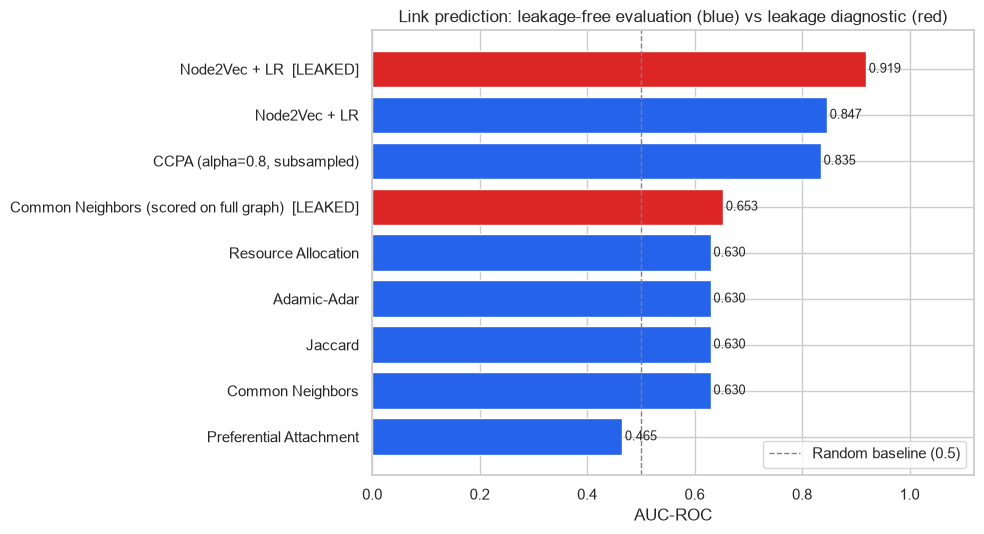

In [35]:
res_df = pd.DataFrame(results)
res_df.to_csv(TABLES / "link_prediction_results.csv", index=False, encoding="utf-8-sig")
display(res_df.sort_values(["protocol", "auc"], ascending=[True, False])
        .reset_index(drop=True))

plot_df = res_df.copy()
plot_df["label"] = plot_df.apply(
    lambda r: r["method"] + ("  [LEAKED]" if r["protocol"] == "leaked" else ""), axis=1)
plot_df = plot_df.sort_values("auc")
colors = ["#dc2626" if p == "leaked" else "#2563eb" for p in plot_df["protocol"]]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(plot_df["label"], plot_df["auc"], color=colors)
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, label="Random baseline (0.5)")
for i, v in enumerate(plot_df["auc"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0, 1.12)
ax.set_xlabel("AUC-ROC")
ax.set_title("Link prediction: leakage-free evaluation (blue) vs leakage diagnostic (red)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES / "method_comparison_auc.png", dpi=150)
plt.show()

## Repeating the test with hard negatives

Uniformly sampled non-edges are often stations in unrelated places, which makes the classification problem too easy. We therefore keep the same positive test edges but replace the negative class with non-edges whose endpoints are two hops apart in `G_train`. These are pairs with a shared local context and are much more plausible missing links.

We reuse the fitted embedding classifier and recompute the structural scores for this new pair set. The difference between random-negative and hard-negative AUC shows how much of each method's apparent performance came from the sampling design. In this run every AUC falls sharply, and Node2Vec drops from 0.8465 to 0.4406, so the good random-negative result does not transfer to this more realistic distinction.

,method,auc_hard_negatives,average_precision,auc_random_negatives,delta
0,Node2Vec + LR,0.4406,0.4709,0.8465,-0.4059
1,Preferential Attachment,0.4044,0.4945,0.4653,-0.0609
2,Common Neighbors,0.1486,0.4371,0.6301,-0.4815
3,Adamic-Adar,0.1004,0.4164,0.6301,-0.5297
4,Jaccard,0.0966,0.4127,0.6301,-0.5335
5,Resource Allocation,0.0946,0.4135,0.6301,-0.5355


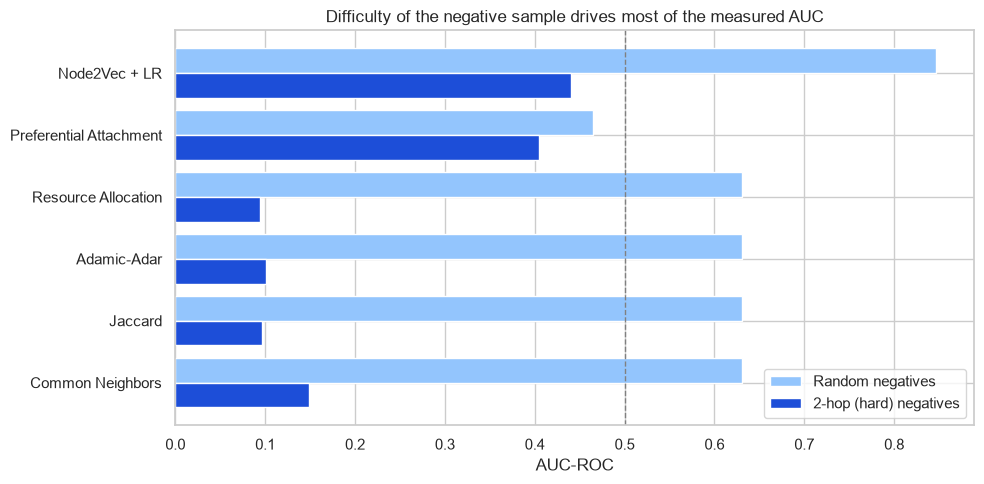

In [36]:
hard_rows = []
hard_classical = pair_scores(G_train, test_pos + hard_neg)
for name, d in hard_classical.items():
    auc, ap = evaluate(test_pos, hard_neg, lookup(d))
    hard_rows.append({"method": name, "auc": auc, "average_precision": ap})

X_h, keep_h = hadamard_matrix(emb_train, test_pos + hard_neg)
y_h = np.array([1] * len(test_pos) + [0] * len(hard_neg))[keep_h]
prob_h = lp_clf.predict_proba(lp_scaler.transform(X_h))[:, 1]
hard_rows.append({"method": "Node2Vec + LR",
                  "auc": round(roc_auc_score(y_h, prob_h), 4),
                  "average_precision": round(average_precision_score(y_h, prob_h), 4)})

hard_df = pd.DataFrame(hard_rows)
easy = res_df[res_df["protocol"] == "valid"].set_index("method")["auc"]
hard_df["auc_random_negatives"] = hard_df["method"].map(easy)
hard_df["delta"] = (hard_df["auc"] - hard_df["auc_random_negatives"]).round(4)
hard_df = hard_df.rename(columns={"auc": "auc_hard_negatives"})
hard_df.to_csv(TABLES / "link_prediction_hard_negatives.csv", index=False,
               encoding="utf-8-sig")
display(hard_df.sort_values("auc_hard_negatives", ascending=False).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 5))
idx = np.arange(len(hard_df))
ax.barh(idx + 0.2, hard_df["auc_random_negatives"], height=0.4, color="#93c5fd",
        label="Random negatives")
ax.barh(idx - 0.2, hard_df["auc_hard_negatives"], height=0.4, color="#1d4ed8",
        label="2-hop (hard) negatives")
ax.set_yticks(idx)
ax.set_yticklabels(hard_df["method"])
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("AUC-ROC")
ax.set_title("Difficulty of the negative sample drives most of the measured AUC")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES / "hard_negatives_comparison.png", dpi=150)
plt.show()

## Ranking possible new links

We now use the complete-graph embeddings descriptively: we look for station pairs that are close in cosine space but do not already share an edge. We normalize every vector, run exact nearest-neighbor search over all embedded stations, remove self-pairs and existing edges, deduplicate the remaining pairs, and rank them by cosine similarity.

This is a global search over all stations rather than a result from a small random subset. `SIM_TOP_M` controls how many neighbors we retain per endpoint before creating the candidate pool; the cell prints the number of distinct non-edges considered. We also calculate great-circle distance and attach station names and regions. The distance column is essential because embedding similarity is structural, not geographic: a highly similar pair can still be far too distant to make sense as one new segment.

Exact cosine kNN over 30,237 nodes in 8s
Candidate non-adjacent pairs considered: 429,319


,name_a,name_b,region_a,region_b,cosine_sim,distance_km
0,שמואל עזר,עשת/טביב,North,North,1.0,0.16
1,מרכז ביג/הסתת,המלחה/חטיבת גולני,South,South,1.0,0.55
2,חטיבת גולני/הסתת,קמפוס אילת/המלחה,South,South,1.0,0.51
3,חטיבת גולני/הסתת,בית אלמוג/המלאכה,South,South,1.0,0.65
4,חטיבת גולני/הסתת,חנה וסע מבואות אילת,South,South,1.0,0.64
5,חטיבת גולני/הסתת,דרבן/קאמן,South,South,1.0,1.64
6,חטיבת גולני/הסתת,מלון לאונרדו קלאב/קאמפן,South,South,1.0,1.55
7,מרכז ביג/הסתת,בית עלמין אילת,South,South,1.0,1.27
8,מרכז ביג/הסתת,חטיבת גולני/הברדלס,South,South,1.0,0.35
9,מרכז ביג/הסתת,חטיבת גולני/המלאכה,South,South,1.0,0.78


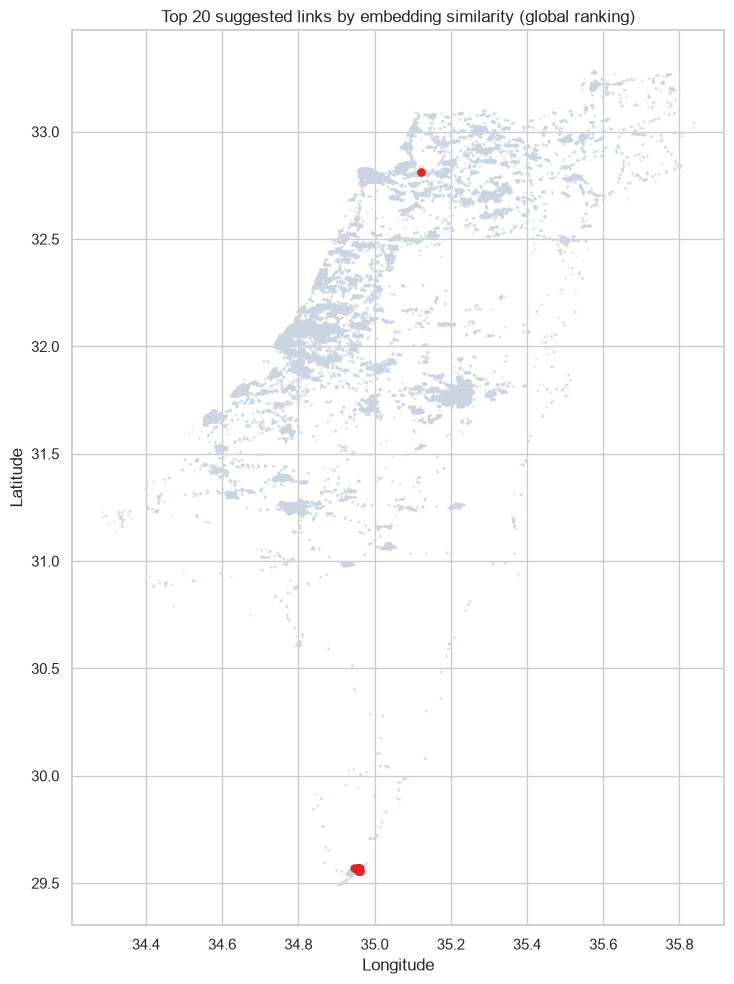

In [37]:
def haversine_km(lat1, lon1, lat2, lon2):
    if None in (lat1, lon1, lat2, lon2):
        return None
    R = 6371.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp, dl = math.radians(lat2 - lat1), math.radians(lon2 - lon1)
    a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    return round(2 * R * math.asin(math.sqrt(a)), 2)

emb_ids = list(emb_full.keys())
M = np.vstack([emb_full[i] for i in emb_ids])
norms = np.linalg.norm(M, axis=1, keepdims=True)
norms[norms == 0] = 1.0
Mn = M / norms

t0 = time.time()
k_nn = min(SIM_TOP_M + 1, len(emb_ids))
nn = NearestNeighbors(n_neighbors=k_nn, metric="cosine", algorithm="brute").fit(Mn)
nn_dist, nn_idx = nn.kneighbors(Mn)
print(f"Exact cosine kNN over {len(emb_ids):,} nodes in {time.time() - t0:.0f}s")

cand = {}
for i, u in enumerate(emb_ids):
    for d, j in zip(nn_dist[i][1:], nn_idx[i][1:]):
        v = emb_ids[j]
        if u == v or Gc.has_edge(u, v):
            continue
        key = (u, v) if u < v else (v, u)
        cand[key] = max(cand.get(key, -1.0), 1.0 - float(d))

sug = pd.DataFrame([{"stop_a": a, "stop_b": b, "cosine_sim": round(s, 4)}
                    for (a, b), s in cand.items()])
sug = sug.sort_values("cosine_sim", ascending=False).head(TOP_K_SUGGEST).reset_index(drop=True)

def attr_of(n, key, default=""):
    return Gc.nodes[n].get(key, default) if n in Gc.nodes else default

for side in ("a", "b"):
    sug["name_" + side] = sug["stop_" + side].map(lambda n: attr_of(n, "stop_name"))
    sug["region_" + side] = sug["stop_" + side].map(lambda n: attr_of(n, "region"))
sug["distance_km"] = [haversine_km(attr_of(a, "lat", None), attr_of(a, "lon", None),
                                   attr_of(b, "lat", None), attr_of(b, "lon", None))
                      for a, b in zip(sug["stop_a"], sug["stop_b"])]
sug.to_csv(TABLES / "top_k_suggested_links.csv", index=False, encoding="utf-8-sig")
print(f"Candidate non-adjacent pairs considered: {len(cand):,}")
display(sug[["name_a", "name_b", "region_a", "region_b", "cosine_sim", "distance_km"]])

fig, ax = plt.subplots(figsize=(7.5, 10))
lats = [d.get("lat") for _, d in Gc.nodes(data=True) if d.get("lat") and d.get("lon")]
lons = [d.get("lon") for _, d in Gc.nodes(data=True) if d.get("lat") and d.get("lon")]
ax.scatter(lons, lats, s=1, color="#cbd5e1", alpha=0.4)
for r in sug.itertuples():
    la, lo = attr_of(r.stop_a, "lat", None), attr_of(r.stop_a, "lon", None)
    lb, lb2 = attr_of(r.stop_b, "lat", None), attr_of(r.stop_b, "lon", None)
    if None in (la, lo, lb, lb2):
        continue
    ax.plot([lo, lb2], [la, lb], "-", color="#dc2626", linewidth=1.5, alpha=0.8)
    ax.scatter([lo, lb2], [la, lb], s=25, color="#dc2626", zorder=5)
ax.set_title(f"Top {len(sug)} suggested links by embedding similarity (global ranking)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig(FIGURES / "suggested_links_map.png", dpi=150)
plt.show()

## Testing whether 20 suggested links change resilience

High cosine similarity does not automatically mean a link adds useful redundancy, so we test the suggestions directly. We add the top 20 candidate edges to a copy of the graph, remove the same highest-degree stations from the original and augmented graphs, and compare the surviving largest-component share across several removal budgets.

The baseline share uses the original node count as its denominator, so the before/after values are comparable. We save every point and the maximum change rather than describing any tiny positive number as meaningful. In this run the largest absolute improvement is only 0.00010, with no change at several budgets. The practical conclusion is that 20 links between structurally similar stations do not alter network-wide connectivity.

,removal_k,lcc_before,lcc_after,delta,delta_pct
0,50,0.9965,0.9965,0.0,0.0
1,200,0.9811,0.9811,0.0,0.0
2,500,0.9627,0.9627,0.0,0.0
3,1000,0.9237,0.9237,0.0,0.0
4,2000,0.7444,0.7444,0.0,0.0


Largest absolute change in LCC share across all removal budgets: 0.00000
Interpretation: no measurable effect - this is a null result.


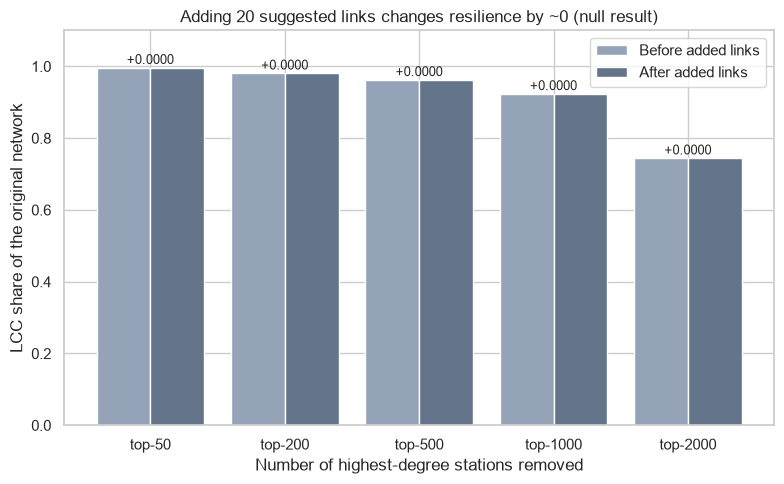

In [38]:
baseline_n = Gc.number_of_nodes()

def lcc_share(H, removed):
    """Largest-component size after removing `removed`, as a share of the original n."""
    T = H.copy()
    T.remove_nodes_from(removed)
    if T.number_of_nodes() == 0:
        return 0.0
    return max(len(c) for c in nx.connected_components(T)) / baseline_n

G_imp = Gc.copy()
for r in sug.itertuples():
    G_imp.add_edge(r.stop_a, r.stop_b, weight=0.002)

ranked = sorted(Gc.nodes(), key=lambda n: Gc.degree(n), reverse=True)
rows = []
for k in REMOVAL_K_GRID:
    before = lcc_share(Gc, ranked[:k])
    after = lcc_share(G_imp, ranked[:k])
    rows.append({"removal_k": k, "lcc_before": round(before, 4),
                 "lcc_after": round(after, 4),
                 "delta": round(after - before, 5),
                 "delta_pct": round((after - before) / before * 100, 3) if before else 0.0})
res_res = pd.DataFrame(rows)
res_res.to_csv(TABLES / "resilience_improvement.csv", index=False, encoding="utf-8-sig")
with open(TABLES / "resilience_improvement.json", "w", encoding="utf-8") as f:
    json.dump({"added_edges": int(len(sug)), "grid": rows}, f, ensure_ascii=False, indent=2)
display(res_res)

max_gain = res_res["delta"].abs().max()
print(f"Largest absolute change in LCC share across all removal budgets: {max_gain:.5f}")
print("Interpretation: " + ("no measurable effect - this is a null result."
                            if max_gain < 0.001 else
                            "a small but non-zero effect; see the table above."))

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(res_res))
ax.bar(x - 0.2, res_res["lcc_before"], width=0.4, color="#94a3b8", label="Before added links")
ax.bar(x + 0.2, res_res["lcc_after"], width=0.4, color="#64748b", label="After added links")
for xi, (b, a) in enumerate(zip(res_res["lcc_before"], res_res["lcc_after"])):
    ax.text(xi, max(b, a) + 0.01, f"{a - b:+.4f}", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([f"top-{k}" for k in res_res["removal_k"]])
ax.set_xlabel("Number of highest-degree stations removed")
ax.set_ylabel("LCC share of the original network")
ax.set_ylim(0, 1.1)
ax.set_title(f"Adding {len(sug)} suggested links changes resilience by ~0 (null result)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "resilience_before_after_links.png", dpi=150)
plt.show()

## Defining critical stations for classification

We need a binary target before asking whether embeddings encode criticality. We label a station critical when it is an articulation point or when its sampled betweenness is in the top 10%. Articulation points are exact; betweenness uses `BETWEENNESS_SAMPLES` pivot sources because an exact all-source calculation on this graph would take much longer.

The cell reports the cut-point count, the sampled threshold, and the final class balance. With 3,660 critical stations out of 30,237, the positive class is about 12.1%, so accuracy alone would be misleading. We use the positive-class F1 score in the next experiment and include baselines that make that score interpretable.

In [39]:
t0 = time.time()
ap_set = set(nx.articulation_points(Gc))
print(f"Articulation points: {len(ap_set):,} ({time.time() - t0:.0f}s)")

t0 = time.time()
btw = nx.betweenness_centrality(Gc, k=min(BETWEENNESS_SAMPLES, Gc.number_of_nodes()),
                                seed=SEED)
btw_thr = float(np.quantile(list(btw.values()), BETWEENNESS_QUANTILE))
print(f"Approximate betweenness with {BETWEENNESS_SAMPLES} pivots "
      f"({time.time() - t0:.0f}s); p{int(BETWEENNESS_QUANTILE * 100)} = {btw_thr:.6f}")

critical = {n: int(n in ap_set or btw.get(n, 0.0) >= btw_thr) for n in Gc.nodes()}
n_crit = sum(critical.values())
print(f"Critical stations: {n_crit:,} / {len(critical):,} "
      f"({n_crit / len(critical) * 100:.1f}%)")

Articulation points: 752 (0s)
Approximate betweenness with 300 pivots (15s); p90 = 0.000620
Critical stations: 3,660 / 30,237 (12.1%)


## Checking whether embeddings encode criticality

We split stations into train and test sets with stratification and compare four predictors of the critical label: logistic regression on the 64 embedding dimensions, random forest on the embeddings, random forest on degree/weighted degree/clustering, and an all-positive baseline that labels every station critical.

The comparison tells us whether the learned vectors add useful information beyond simple graph structure. On this run, embedding logistic regression reaches F1 0.3327 and the embedding random forest 0.4209. The three-feature structural model reaches 0.3564, while predicting every station as critical gives 0.2159. The embedding random forest is the strongest of the four, but its margin over the three-feature structural model is small and every model stays close to the all-positive baseline, so classifier choice matters as much as the representation.

--- Embeddings + LogisticRegression: F1 = 0.3327
              precision    recall  f1-score   support

     regular       0.92      0.79      0.85      5316
    critical       0.25      0.51      0.33       732

    accuracy                           0.75      6048
   macro avg       0.58      0.65      0.59      6048
weighted avg       0.84      0.75      0.79      6048

--- Embeddings + RandomForest: F1 = 0.4209
              precision    recall  f1-score   support

     regular       0.92      0.92      0.92      5316
    critical       0.43      0.41      0.42       732

    accuracy                           0.86      6048
   macro avg       0.67      0.67      0.67      6048
weighted avg       0.86      0.86      0.86      6048

--- Degree/clustering + RandomForest: F1 = 0.3564
              precision    recall  f1-score   support

     regular       0.93      0.80      0.86      5316
    critical       0.27      0.53      0.36       732

    accuracy                           0

,model,f1_critical
0,Embeddings + LogisticRegression,0.3327
1,Embeddings + RandomForest,0.4209
2,Degree/clustering + RandomForest,0.3564
3,Always critical (all-positive) baseline,0.2159


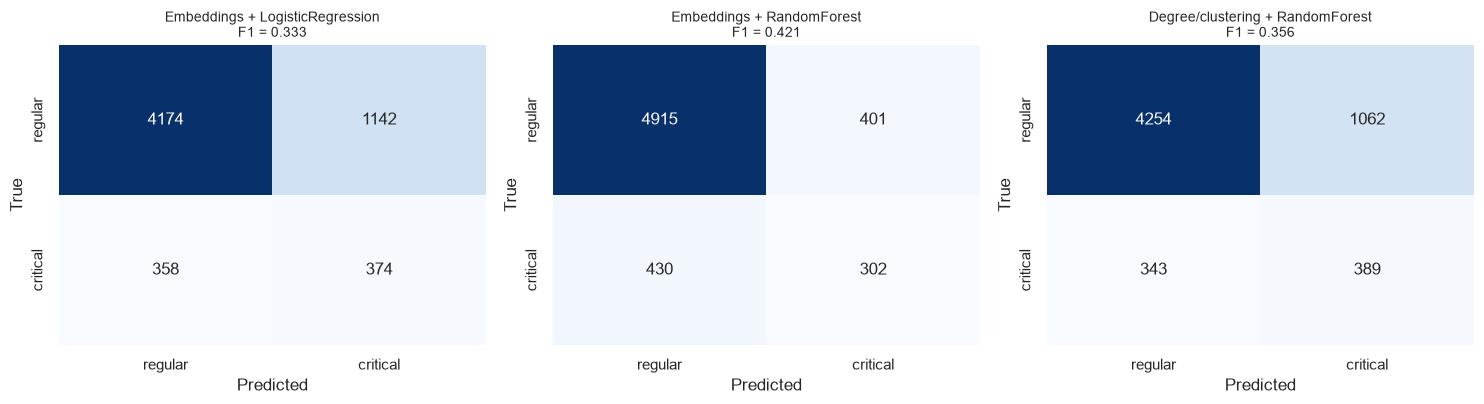

In [40]:
clf_ids = [n for n in Gc.nodes() if n in emb_full]
X_emb = np.vstack([emb_full[n] for n in clf_ids])
y = np.array([critical[n] for n in clf_ids])

clustering = nx.clustering(Gc)
X_struct = np.array([[Gc.degree(n),
                      Gc.degree(n, weight="weight"),
                      clustering.get(n, 0.0)] for n in clf_ids], dtype=float)

idx_tr, idx_te = train_test_split(np.arange(len(clf_ids)), test_size=0.2,
                                  random_state=SEED, stratify=y)

def run_classifier(name, X, clf):
    scaler = StandardScaler().fit(X[idx_tr])
    clf.fit(scaler.transform(X[idx_tr]), y[idx_tr])
    pred = clf.predict(scaler.transform(X[idx_te]))
    f1 = f1_score(y[idx_te], pred, average="binary", zero_division=0)
    print(f"--- {name}: F1 = {f1:.4f}")
    print(classification_report(y[idx_te], pred, target_names=["regular", "critical"],
                                zero_division=0))
    return {"model": name, "f1_critical": round(float(f1), 4),
            "confusion": confusion_matrix(y[idx_te], pred).tolist()}

clf_rows = [
    run_classifier("Embeddings + LogisticRegression", X_emb,
                   LogisticRegression(class_weight="balanced", max_iter=500,
                                      random_state=SEED)),
    run_classifier("Embeddings + RandomForest", X_emb,
                   RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                          random_state=SEED, n_jobs=-1)),
    run_classifier("Degree/clustering + RandomForest", X_struct,
                   RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                          random_state=SEED, n_jobs=-1)),
]

base_rate = float(y.mean())
all_positive_f1 = 2 * base_rate / (1 + base_rate)  # precision = base rate, recall = 1
clf_rows.append({"model": "Always critical (all-positive) baseline",
                 "f1_critical": round(all_positive_f1, 4), "confusion": None})
print(f"Base rate of critical stations: {base_rate:.3f} "
      f"-> predicting every station as critical gives F1 = {all_positive_f1:.4f}")

clf_df = pd.DataFrame([{k: v for k, v in r.items() if k != "confusion"} for r in clf_rows])
clf_df.to_csv(TABLES / "critical_classifier_results.csv", index=False, encoding="utf-8-sig")
display(clf_df)

cms = [r for r in clf_rows if r["confusion"] is not None]
fig, axes = plt.subplots(1, len(cms), figsize=(5 * len(cms), 4.2))
for ax, r in zip(np.atleast_1d(axes), cms):
    sns.heatmap(np.array(r["confusion"]), annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["regular", "critical"], yticklabels=["regular", "critical"],
                ax=ax)
    ax.set_title(f"{r['model']}\nF1 = {r['f1_critical']:.3f}", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(FIGURES / "confusion_matrices.png", dpi=150)
plt.show()

## Looking at what the embedding space captures

Since the vectors are much better at local similarity than at criticality, we project them to two dimensions and inspect what is organized in the space. We calculate Louvain communities on the full graph, make a t-SNE projection of a fixed random sample, and make a PCA projection using all available vectors.

We color otherwise identical plots by geographic area, Louvain community, and the critical label. If geography and community form visible groups while critical stations are spread throughout them, that matches the idea that random-walk context captures where a station belongs more naturally than whether its removal creates a cut. The projection is descriptive only: t-SNE distances between far-apart clusters are not a metric we use elsewhere.

Louvain: 74 communities in 1s
t-SNE on 6,000 nodes in 2s


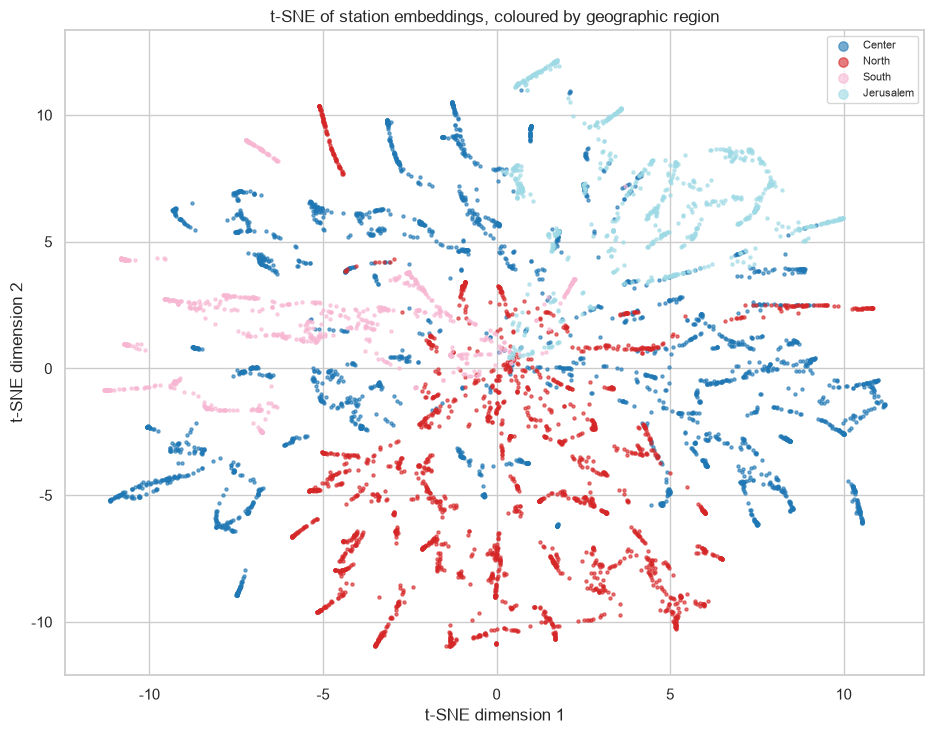

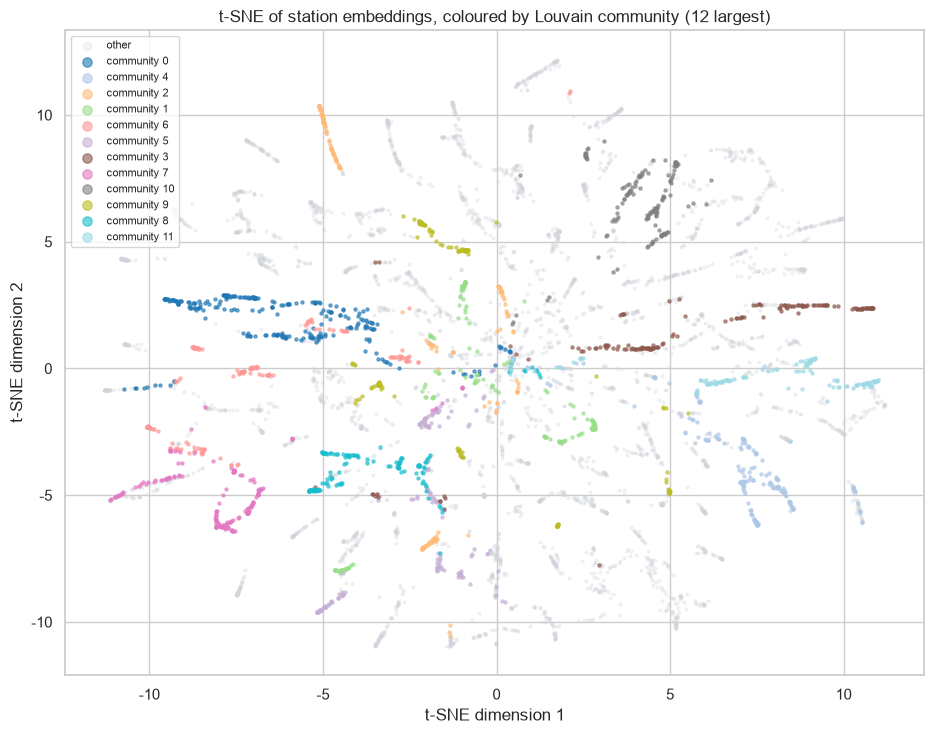

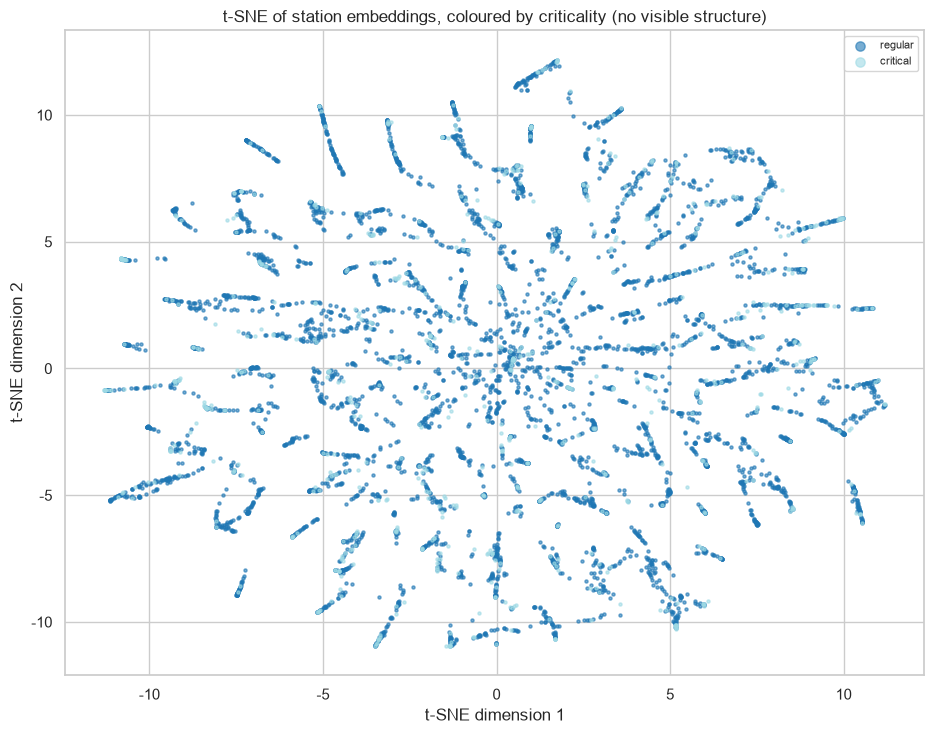

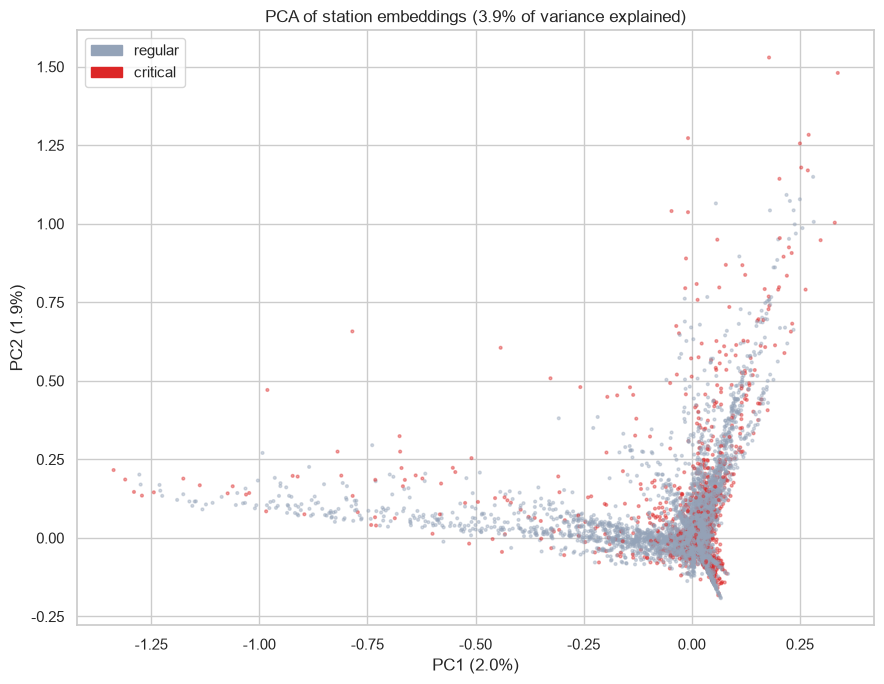

In [41]:
t0 = time.time()
communities = nx.community.louvain_communities(Gc, seed=SEED, weight="weight")
comm_of = {n: i for i, c in enumerate(sorted(communities, key=len, reverse=True))
           for n in c}
print(f"Louvain: {len(communities):,} communities in {time.time() - t0:.0f}s")

vis_rng = random.Random(SEED)
vis_ids = vis_rng.sample(clf_ids, min(TSNE_SAMPLE, len(clf_ids)))
X_vis = np.vstack([emb_full[n] for n in vis_ids])

t0 = time.time()
perp = min(30, max(5, len(vis_ids) - 1))
try:
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=perp, max_iter=300, init="pca")
except TypeError:  # scikit-learn < 1.5 calls the parameter n_iter
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=perp, n_iter=300, init="pca")
XY = tsne.fit_transform(X_vis)
print(f"t-SNE on {len(vis_ids):,} nodes in {time.time() - t0:.0f}s")

def scatter_by(labels, title, fname, max_cats=12):
    counts = pd.Series(labels).value_counts()
    keep = list(counts.index[:max_cats])
    cmap = matplotlib.colormaps.get_cmap("tab20").resampled(max(len(keep), 2))
    fig, ax = plt.subplots(figsize=(9.5, 7.5))
    other = [i for i, l in enumerate(labels) if l not in keep]
    if other:
        ax.scatter(XY[other, 0], XY[other, 1], s=4, alpha=0.25, color="#d1d5db",
                   label="other")
    for ci, lab in enumerate(keep):
        sel = [i for i, l in enumerate(labels) if l == lab]
        ax.scatter(XY[sel, 0], XY[sel, 1], s=5, alpha=0.6, color=cmap(ci), label=str(lab))
    ax.legend(markerscale=3, fontsize=8, loc="best")
    ax.set_title(title)
    ax.set_xlabel("t-SNE dimension 1")
    ax.set_ylabel("t-SNE dimension 2")
    plt.tight_layout()
    plt.savefig(FIGURES / fname, dpi=150)
    plt.show()

scatter_by([Gc.nodes[n].get("region", "?") or "?" for n in vis_ids],
           "t-SNE of station embeddings, coloured by geographic region",
           "tsne_by_region.png")
scatter_by([f"community {comm_of.get(n, -1)}" for n in vis_ids],
           "t-SNE of station embeddings, coloured by Louvain community (12 largest)",
           "tsne_by_community.png")
scatter_by(["critical" if critical[n] else "regular" for n in vis_ids],
           "t-SNE of station embeddings, coloured by criticality (no visible structure)",
           "tsne_by_criticality.png", max_cats=2)

pca = PCA(n_components=2, random_state=SEED)
P = pca.fit_transform(X_emb)
fig, ax = plt.subplots(figsize=(9, 7))
cols = ["#dc2626" if critical[n] else "#94a3b8" for n in clf_ids]
ax.scatter(P[:, 0], P[:, 1], s=4, alpha=0.4, c=cols)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#94a3b8", label="regular"),
                   Patch(color="#dc2626", label="critical")])
ax.set_title(f"PCA of station embeddings "
             f"({pca.explained_variance_ratio_.sum() * 100:.1f}% of variance explained)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.tight_layout()
plt.savefig(FIGURES / "pca_embeddings.png", dpi=150)
plt.show()

## Checking nearest stations in embedding space

We finish with a direct sanity check that is easier to read than a projection. For five stations spread through the embedding index, we list the ten closest vectors, their cosine similarities, names, and regions. The code reuses the exact nearest-neighbor model built for candidate links and writes the result to `station_similarity.csv`.

In this run, every listed nearest neighbor is in the target station's region. That does not prove the vectors solve link prediction, but it confirms that they learned coherent geographic and service-context neighborhoods rather than random noise.

In [42]:
sample_positions = [0, len(emb_ids) // 5, len(emb_ids) // 3,
                    len(emb_ids) // 2, len(emb_ids) * 3 // 4]
sim_rows = []
for pos in sample_positions:
    target = emb_ids[pos]
    for rank, (d, j) in enumerate(zip(nn_dist[pos][1:11], nn_idx[pos][1:11]), 1):
        other = emb_ids[j]
        sim_rows.append({
            "target_stop": target,
            "target_name": attr_of(target, "stop_name"),
            "rank": rank,
            "similar_stop": other,
            "similar_name": attr_of(other, "stop_name"),
            "same_region": attr_of(target, "region") == attr_of(other, "region"),
            "is_existing_edge": Gc.has_edge(target, other),
            "cosine_similarity": round(1.0 - float(d), 4),
        })
sim_df = pd.DataFrame(sim_rows)
sim_df.to_csv(TABLES / "station_similarity.csv", index=False, encoding="utf-8-sig")
print(f"Share of nearest neighbours in the same region: "
      f"{sim_df['same_region'].mean() * 100:.1f}%")
display(sim_df[sim_df["rank"] <= 3][["target_name", "rank", "similar_name",
                                     "same_region", "cosine_similarity"]])

Share of nearest neighbours in the same region: 100.0%


,target_name,rank,similar_name,same_region,cosine_similarity
0,בי''ס בר לב/בן יהודה,1,אז''ר/תל חי,True,0.9978
1,בי''ס בר לב/בן יהודה,2,אז''ר/בר אילן,True,0.9968
2,בי''ס בר לב/בן יהודה,3,בי''ס גורדון/הגליל,True,0.9897
10,צומת מירון,1,צומת עין זיתים,True,0.9983
11,צומת מירון,2,מועצה אזורית/מרום הגליל,True,0.9948
12,צומת מירון,3,מירון שער כחול,True,0.9942
20,מכללת אורנים,1,מזרח/נחל קדומים,True,0.9986
21,מכללת אורנים,2,אלרואי/מזרח,True,0.9976
22,מכללת אורנים,3,רכבת העמק/מזרח,True,0.9975
30,בי''ס היובל/דולצ'ין,1,מרכז מסחרי/דולצ'ין,True,0.9997


## Conclusion

The valid link-prediction result is much more modest than the leaked diagnostic. Node2Vec plus logistic regression reaches AUC 0.8465 when the embeddings are learned after removing the test edges; letting the walks see those edges raises the score to 0.9191. Our takeaway is simple: we have to split the graph first and learn every representation from the training graph only.

Node2Vec is the strongest valid method in the random-negative test at AUC 0.8465, just above CCPA at 0.8351. Plain Common Neighbors, Jaccard, Adamic-Adar, and Resource Allocation all sit around 0.63 because this sparse graph gives most pairs very little neighborhood overlap. CCPA stays close partly because of its shortest-path term, which can easily separate a removed edge from two stations chosen randomly far apart.

The hard-negative test changes the interpretation. When the negative pairs are non-edges two hops apart, all methods deteriorate and Node2Vec falls to AUC 0.4406, still below random guessing. This means the random-negative scores mostly show that the methods distinguish nearby stations from unrelated ones; they do not show reliable discrimination among plausible missing links.

The embedding space itself is still useful descriptively. Its nearest neighbors stay in the same region in this check, and the projections organize stations by geography and community. It is less useful for the critical-station target: the best embedding model reaches F1 0.4209, above the simple degree/clustering model at 0.3564, but both stay close to the 0.2159 all-positive baseline. We would keep articulation-point and betweenness calculations as the main tools for structural criticality.

The proposed links also give a clear negative result. Adding the top 20 high-similarity non-edges leaves largest-component share unchanged at every tested removal budget. Similar stations are usually already embedded in similar, well-connected neighborhoods, so connecting them does not necessarily bridge a vulnerable cut. If we want resilience-oriented additions, we need an objective based on cuts or rerouting damage rather than cosine similarity alone.